#Muhammad Ridwan Cahyadi - 103012340199


# PneumoVision — Pneumonia Detection from Chest X-Rays

This project applies Digital Image Processing and Machine Learning techniques to classify chest X-ray images as **Normal** or **Pneumonia**. The objective is to compare a traditional image-processing pipeline with a modern deep-learning approach and evaluate their performance on the same dataset.

The notebook implements two classification strategies:

* **Classical Machine Learning:** Images are enhanced through pre-processing, followed by feature extraction using GLCM, LBP, and Hu Moments. The extracted features are then classified using algorithms such as SVM and Random Forest.
* **Deep Learning:** A pre-trained DenseNet121 model is fine-tuned using transfer learning to automatically learn discriminative features from chest X-ray images.

The workflow follows four main stages:

1. **Pre-processing** – Image denoising, contrast enhancement, and resizing.
2. **Feature Extraction** – GLCM, LBP, and Hu Moments for handcrafted image representation.
3. **Classification** – SVM, Random Forest, and DenseNet121.
4. **Evaluation** – Accuracy, Precision, Recall, F1-Score, ROC-AUC, Confusion Matrix, and Grad-CAM visualization.

By comparing traditional feature-based methods with deep learning, this project demonstrates how different image classification approaches can be applied to a real-world medical imaging problem.


## 0. Setup

This section imports all required libraries and verifies that GPU acceleration is available in the Colab environment. Google Colab provides most of the necessary packages by default, including TensorFlow, OpenCV, scikit-image, and scikit-learn, making it a convenient platform for developing and training image classification models. Ensuring that a GPU is enabled is important because it significantly reduces the training time of deep learning models such as DenseNet121.


In [ ]:
import os, time, json, shutil, numpy as np, matplotlib.pyplot as plt, cv2
import tensorflow as tf
print("TensorFlow:", tf.__version__)
print("GPU available:", bool(tf.config.list_physical_devices('GPU')))

TensorFlow: 2.20.0
GPU available: True


## 1. Load the Dataset from Google Drive

The chest X-ray dataset is stored in Google Drive and accessed by mounting the Drive to the Colab environment. After locating the dataset directory, the training and testing folders are verified to ensure the dataset is correctly organized.

To improve performance, the dataset is copied from Google Drive to Colab's local storage before training. Reading large numbers of images directly from Drive can create significant I/O overhead, especially during multiple training epochs. By using the local storage provided by Colab, image loading becomes much faster, resulting in more efficient model training and evaluation.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Dataset folder (contains train/ and test/ with NORMAL & PNEUMONIA subfolders) <<<
BASE = "/content/drive/MyDrive/Colab Notebooks/PCD Final Project/Dataset/chest_xray"
assert os.path.isdir(BASE), f"Folder not found: {BASE}"

# Copy Drive -> local disk for much faster I/O. Set False to read from Drive directly.
COPY_LOCAL = True
if COPY_LOCAL:
    LOCAL = "/content/chest_xray"
    if not os.path.isdir(LOCAL):
        print("Copying dataset to local disk (one-time, ~1-3 min)...")
        shutil.copytree(BASE, LOCAL)
        print("Done.")
    BASE = LOCAL

TRAIN_DIR = os.path.join(BASE, "train")
TEST_DIR  = os.path.join(BASE, "test")
assert os.path.isdir(TRAIN_DIR), f"Not found: {TRAIN_DIR}"
assert os.path.isdir(TEST_DIR),  f"Not found: {TEST_DIR}"
CLASSES = ["NORMAL", "PNEUMONIA"]
print("Using dataset at:", BASE)

Mounted at /content/drive
Copying dataset to local disk (one-time, ~1-3 min)...
Done.
Using dataset at: /content/chest_xray


## 2. Exploratory Data Analysis (EDA)

Before building any models, it is important to understand the dataset's composition and characteristics. This section examines the number of images in each class and visualizes sample chest X-ray images from both the **Normal** and **Pneumonia** categories.

Performing this initial analysis helps identify potential issues such as class imbalance, image quality variations, and differences in visual patterns between classes. The dataset contains considerably more pneumonia cases than normal cases, which may bias the models toward the majority class. Understanding this imbalance early allows appropriate strategies to be applied during training and evaluation to ensure fair and reliable performance assessment.


Train: {'NORMAL': 1341, 'PNEUMONIA': 3886}
Test : {'NORMAL': 234, 'PNEUMONIA': 390}


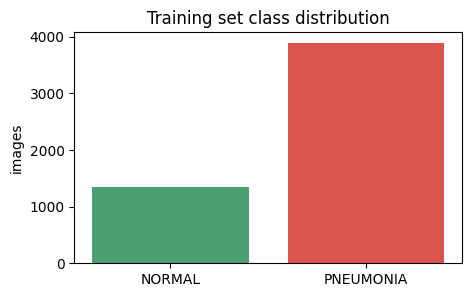

In [ ]:
def count_images(d):
    return {c: len(os.listdir(os.path.join(d, c))) for c in CLASSES}

train_counts, test_counts = count_images(TRAIN_DIR), count_images(TEST_DIR)
print("Train:", train_counts)
print("Test :", test_counts)

plt.figure(figsize=(5,3))
plt.bar(train_counts.keys(), train_counts.values(), color=["#4C9F70","#D9534F"])
plt.title("Training set class distribution"); plt.ylabel("images"); plt.show()

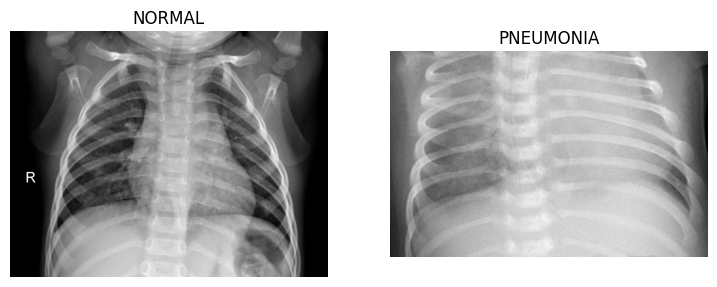

In [ ]:
# Show one NORMAL and one PNEUMONIA sample
fig, axes = plt.subplots(1, 2, figsize=(9,4))
for ax, c in zip(axes, CLASSES):
    folder = os.path.join(TRAIN_DIR, c)
    fname = os.listdir(folder)[0]
    img = cv2.imread(os.path.join(folder, fname), cv2.IMREAD_GRAYSCALE)
    ax.imshow(img, cmap="gray"); ax.set_title(c); ax.axis("off")
plt.show()

## 3. Pre-processing *(Stage 1)*

Chest X-ray images often contain noise and low contrast, which can make important lung patterns harder to detect. To improve image quality, denoising filters (Median and Gaussian) are applied, followed by contrast enhancement using CLAHE and contrast stretching.

These pre-processing methods are implemented as optional settings so they can be enabled or disabled during experiments. This allows an ablation study to measure the impact of each technique on the final classification performance.


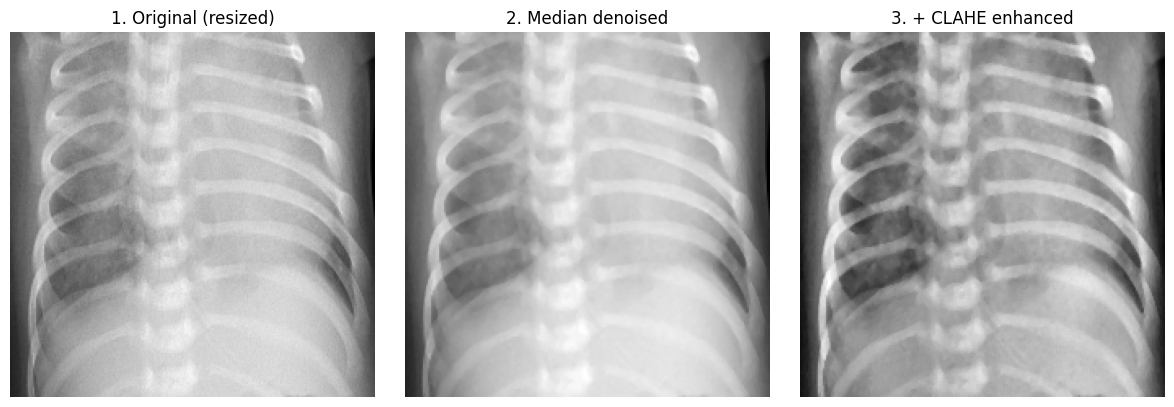

In [ ]:
IMG_SIZE = 224

def preprocess_gray(gray, denoise="median", enhance="clahe"):
    """Resize -> denoise -> contrast-enhance. Input/output: uint8 grayscale."""
    g = cv2.resize(gray, (IMG_SIZE, IMG_SIZE))
    if denoise == "median":
        g = cv2.medianBlur(g, 3)
    elif denoise == "gaussian":
        g = cv2.GaussianBlur(g, (3, 3), 0)
    if enhance == "clahe":
        g = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(g)
    elif enhance == "hist_eq":
        g = cv2.equalizeHist(g)
    elif enhance == "stretch":
        lo, hi = np.percentile(g, (2, 98))
        g = np.clip((g - lo) * 255.0 / max(hi - lo, 1), 0, 255).astype(np.uint8)
    return g

# Visualize the pipeline on one image (great figure for your report)
sample = cv2.imread(os.path.join(TRAIN_DIR, "PNEUMONIA",
                    os.listdir(os.path.join(TRAIN_DIR, "PNEUMONIA"))[0]), cv2.IMREAD_GRAYSCALE)
stages = {
    "1. Original (resized)": preprocess_gray(sample, "none", "none"),
    "2. Median denoised":    preprocess_gray(sample, "median", "none"),
    "3. + CLAHE enhanced":   preprocess_gray(sample, "median", "clahe"),
}
fig, axes = plt.subplots(1, 3, figsize=(12,4))
for ax,(t,im) in zip(axes, stages.items()):
    ax.imshow(im, cmap="gray"); ax.set_title(t); ax.axis("off")
plt.tight_layout(); plt.savefig("preprocessing_stages.png", dpi=130, bbox_inches="tight"); plt.show()

In [ ]:
# Helper: turn a preprocessed grayscale image into 3-channel input for the CNN
def to_rgb(gray_u8):
    return cv2.cvtColor(gray_u8, cv2.COLOR_GRAY2RGB)

---

# Pipeline A — Classical Machine Learning Approach

This pipeline follows the traditional Digital Image Processing workflow. Instead of learning features automatically, the images are represented using handcrafted texture and shape descriptors extracted during feature extraction. These numerical features are then used to train machine learning classifiers such as SVM and Random Forest.

The purpose of this pipeline is to serve as a baseline and provide a direct comparison with the deep learning approach implemented later in the project.


## Feature Extraction *(Stage 2)*

Each image is converted into a numerical feature vector using three complementary feature extraction methods. **GLCM** captures texture characteristics such as contrast, homogeneity, energy, correlation, and dissimilarity. **LBP** describes local texture patterns and is robust to small variations in appearance, while **Hu Moments** provide shape-based features that are invariant to translation, rotation, and scaling.

These features are combined into a single feature vector that represents each chest X-ray image and serves as input for the machine learning classifiers.


In [ ]:
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern

def extract_features(gray_u8):
    feats = []
    # --- GLCM (quantize to 64 levels for speed) ---
    q = (gray_u8 / 4).astype(np.uint8)
    glcm = graycomatrix(q, distances=[1], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                        levels=64, symmetric=True, normed=True)
    for prop in ["contrast","homogeneity","energy","correlation","dissimilarity"]:
        feats.extend(graycoprops(glcm, prop).ravel())     # 4 values each
    # --- LBP histogram (uniform, P=8, R=1) ---
    P, R = 8, 1
    lbp = local_binary_pattern(gray_u8, P, R, method="uniform")
    hist,_ = np.histogram(lbp.ravel(), bins=P+2, range=(0, P+2), density=True)
    feats.extend(hist)
    # --- Hu moments (log-scaled for numerical stability) ---
    hu = cv2.HuMoments(cv2.moments(gray_u8)).ravel()
    hu = -np.sign(hu) * np.log10(np.abs(hu) + 1e-12)
    feats.extend(hu)
    return np.array(feats, dtype=np.float32)

print("Feature vector length:", len(extract_features(preprocess_gray(sample))))

Feature vector length: 37


In [ ]:
# Build the feature matrix. We cap images per class to keep this fast AND balanced.
MAX_PER_CLASS = 1500   # raise to None to use everything (slower)

def build_dataset(directory, max_per_class=None, denoise="median", enhance="clahe"):
    X, y = [], []
    for label, c in enumerate(CLASSES):
        folder = os.path.join(directory, c)
        files = sorted(os.listdir(folder))
        if max_per_class: files = files[:max_per_class]
        for fn in files:
            img = cv2.imread(os.path.join(folder, fn), cv2.IMREAD_GRAYSCALE)
            if img is None: continue
            X.append(extract_features(preprocess_gray(img, denoise, enhance)))
            y.append(label)
    return np.array(X), np.array(y)

t0 = time.time()
Xtr, ytr = build_dataset(TRAIN_DIR, MAX_PER_CLASS)
Xte, yte = build_dataset(TEST_DIR,  None)
print(f"Extracted in {time.time()-t0:.0f}s  |  train {Xtr.shape}  test {Xte.shape}")

Extracted in 91s  |  train (2841, 37)  test (624, 37)


## Training the Classifiers *(Stage 3)*

Before training, the extracted features are normalized to ensure that all feature values are on a comparable scale, which is particularly important for SVM performance. The feature vectors are then used to train both an **SVM** and a **Random Forest** classifier.

To address the class imbalance in the dataset, balanced class weights are applied so that the models place greater emphasis on the minority class during training.


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline

svm = make_pipeline(StandardScaler(),
                    SVC(kernel="rbf", C=10, gamma="scale",
                        class_weight="balanced", probability=True))
rf  = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42)

svm.fit(Xtr, ytr); rf.fit(Xtr, ytr)
print("Classical models trained.")

Classical models trained.


## Performance Evaluation *(Stage 4)*

Model performance is evaluated using multiple metrics to provide a more complete assessment than accuracy alone. In addition to **Accuracy**, **Precision**, **Recall**, and **F1-Score** are used to measure classification performance for each class. A **Confusion Matrix** helps visualize prediction errors, while **ROC-AUC** evaluates the model's ability to distinguish between Normal and Pneumonia cases across different decision thresholds.



===== SVM (texture features) =====
              precision    recall  f1-score   support

      NORMAL      0.776     0.517     0.621       234
   PNEUMONIA      0.759     0.910     0.828       390

    accuracy                          0.763       624
   macro avg      0.767     0.714     0.724       624
weighted avg      0.765     0.763     0.750       624

ROC-AUC: 0.802


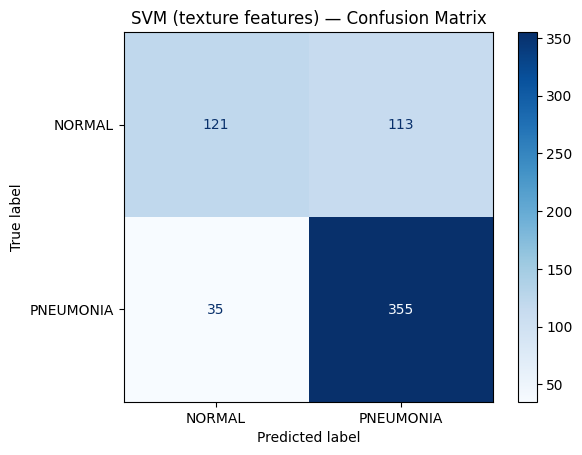


===== Random Forest =====
              precision    recall  f1-score   support

      NORMAL      0.755     0.526     0.620       234
   PNEUMONIA      0.759     0.897     0.823       390

    accuracy                          0.758       624
   macro avg      0.757     0.712     0.721       624
weighted avg      0.757     0.758     0.746       624

ROC-AUC: 0.838


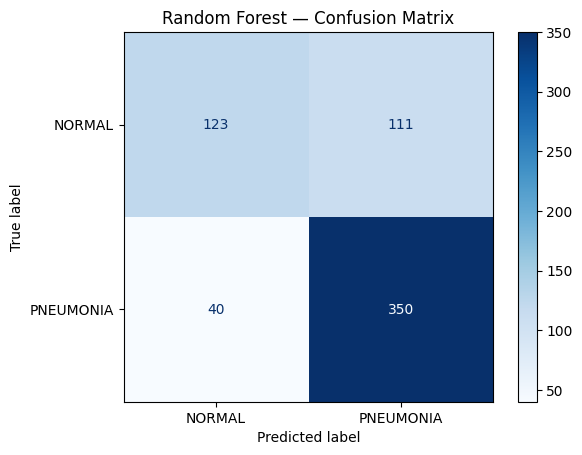

In [ ]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score, roc_curve)

def evaluate(name, y_true, y_pred, y_score):
    print(f"\n===== {name} =====")
    print(classification_report(y_true, y_pred, target_names=CLASSES, digits=3))
    print("ROC-AUC:", round(roc_auc_score(y_true, y_score), 3))
    ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred),
                           display_labels=CLASSES).plot(cmap="Blues")
    plt.title(f"{name} — Confusion Matrix"); plt.show()
    return {"name": name, "auc": float(roc_auc_score(y_true, y_score))}

svm_res = evaluate("SVM (texture features)", yte, svm.predict(Xte), svm.predict_proba(Xte)[:,1])
rf_res  = evaluate("Random Forest",          yte, rf.predict(Xte),  rf.predict_proba(Xte)[:,1])

---

# Pipeline B — Deep Transfer Learning (DenseNet121)

This pipeline uses a deep learning approach based on **DenseNet121**, a convolutional neural network pre-trained on ImageNet. Instead of relying on handcrafted features, the model automatically learns relevant visual patterns directly from the chest X-ray images through transfer learning.

The network is fine-tuned for binary classification (Normal vs. Pneumonia) using the same pre-processed images from the previous pipeline. This enables a direct comparison between traditional feature-based methods and deep learning, while also allowing the impact of CLAHE enhancement on CNN performance to be evaluated.


## Setting Up the Image Pipeline

The images are loaded in batches and preprocessed before being passed to the network. A custom pipeline applies CLAHE enhancement to improve local contrast and highlight important lung structures.

To obtain a more reliable validation set, 15% of the training data is reserved for validation during training. Although the dataset includes a predefined validation folder, it contains only a small number of images and is therefore not suitable for monitoring model performance. The `USE_CLAHE` parameter allows preprocessing to be enabled or disabled for later ablation experiments.


In [ ]:
from tensorflow.keras.applications.densenet import preprocess_input as densenet_pre
AUTOTUNE = tf.data.AUTOTUNE
BATCH = 32

# Load unbatched so we can map a per-image CLAHE step, then batch.
raw_train = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, labels="inferred", label_mode="binary", class_names=CLASSES,
    color_mode="rgb", image_size=(IMG_SIZE, IMG_SIZE), batch_size=None,
    shuffle=True, seed=42, validation_split=0.15, subset="training")
raw_val = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, labels="inferred", label_mode="binary", class_names=CLASSES,
    color_mode="rgb", image_size=(IMG_SIZE, IMG_SIZE), batch_size=None,
    shuffle=True, seed=42, validation_split=0.15, subset="validation")
raw_test = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR, labels="inferred", label_mode="binary", class_names=CLASSES,
    color_mode="rgb", image_size=(IMG_SIZE, IMG_SIZE), batch_size=None, shuffle=False)

USE_CLAHE = True   # set False for the ablation run (no DIP enhancement)

def clahe_map(image, label):
    def _f(img):
        u8 = img.numpy().astype("uint8")
        g  = cv2.cvtColor(u8, cv2.COLOR_RGB2GRAY)
        g  = cv2.createCLAHE(2.0, (8,8)).apply(g)
        return cv2.cvtColor(g, cv2.COLOR_GRAY2RGB).astype("float32")
    out = tf.py_function(_f, [image], tf.float32)
    out.set_shape((IMG_SIZE, IMG_SIZE, 3))
    return out, label

def prepare(ds, training=False):
    if USE_CLAHE:
        ds = ds.map(clahe_map, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH)
    if training:
        aug = tf.keras.Sequential([tf.keras.layers.RandomFlip("horizontal"),
                                   tf.keras.layers.RandomRotation(0.05),
                                   tf.keras.layers.RandomZoom(0.1)])
        ds = ds.map(lambda x,y: (aug(x, training=True), y), num_parallel_calls=AUTOTUNE)
    return ds.prefetch(AUTOTUNE)

train_ds = prepare(raw_train, training=True)
val_ds   = prepare(raw_val)
test_ds  = prepare(raw_test)

Found 5227 files belonging to 2 classes.
Using 4443 files for training.
Found 5227 files belonging to 2 classes.
Using 784 files for validation.
Found 624 files belonging to 2 classes.


## Class Weights

To address the class imbalance in the dataset, class weights are computed and applied during training. This increases the importance of the minority class, helping the model learn balanced decision boundaries rather than favoring the majority class.


In [ ]:
n_normal, n_pneu = train_counts["NORMAL"], train_counts["PNEUMONIA"]
total = n_normal + n_pneu
class_weight = {0: total/(2*n_normal), 1: total/(2*n_pneu)}
print("class_weight:", class_weight)

class_weight: {0: 1.9489187173750933, 1: 0.6725424601132269}


## Building the Model

The model is built using a pre-trained DenseNet121 backbone as a feature extractor. Initially, the base network is frozen so that the pre-trained weights remain unchanged while a custom classification head is trained on the chest X-ray dataset.

The classification head consists of a global pooling layer, dropout for regularization, and a single output neuron for binary classification (Normal vs. Pneumonia). References to key layers are also retained for later use in Grad-CAM visualization and model interpretation.


In [ ]:
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.applications import DenseNet121

base = DenseNet121(include_top=False, weights="imagenet",
                   input_shape=(IMG_SIZE, IMG_SIZE, 3))
base.trainable = False     # phase 1: train only the head

gap  = layers.GlobalAveragePooling2D(name="gap")
drop = layers.Dropout(0.3, name="drop")
pred = layers.Dense(1, activation="sigmoid", name="pred")

inp  = Input((IMG_SIZE, IMG_SIZE, 3))
x    = densenet_pre(inp)            # ImageNet normalization
feat = base(x, training=False)
y    = pred(drop(gap(feat)))
model = Model(inp, y)
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss="binary_crossentropy",
              metrics=["accuracy", tf.keras.metrics.AUC(name="auc"),
                       tf.keras.metrics.Precision(name="prec"),
                       tf.keras.metrics.Recall(name="rec")])
model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop (Dropout)                  │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pred (Dense)                    │ (None, 1)              │         1,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,038,529 (26.85 MB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

## Training the Model

Training is performed in two stages. First, the DenseNet121 backbone is kept frozen while only the newly added classification layers are trained. This allows the model to adapt to the pneumonia classification task without modifying the pre-trained feature representations.

Afterward, the upper layers of DenseNet121 are unfrozen and fine-tuned using a small learning rate. This enables the network to learn task-specific features while preserving the knowledge gained during pre-training. A relatively small number of epochs is used to balance training time and performance within the constraints of the free Colab GPU environment.


In [ ]:
cb = [tf.keras.callbacks.EarlyStopping(monitor="val_auc", mode="max",
                                       patience=3, restore_best_weights=True)]
hist1 = model.fit(train_ds, validation_data=val_ds, epochs=6,
                  class_weight=class_weight, callbacks=cb)

Epoch 1/6
139/139 ━━━━━━━━━━━━━━━━━━━━ 159s 903ms/step - accuracy: 0.7657 - auc: 0.8513 - loss: 0.4808 - prec: 0.9059 - rec: 0.7631 - val_accuracy: 0.8903 - val_auc: 0.9784 - val_loss: 0.2971 - val_prec: 0.9884 - val_rec: 0.8651
Epoch 2/6
139/139 ━━━━━━━━━━━━━━━━━━━━ 88s 627ms/step - accuracy: 0.8717 - auc: 0.9462 - loss: 0.3080 - prec: 0.9552 - rec: 0.8676 - val_accuracy: 0.8929 - val_auc: 0.9815 - val_loss: 0.2800 - val_prec: 0.9904 - val_rec: 0.8668
Epoch 3/6
139/139 ━━━━━━━━━━━━━━━━━━━━ 139s 606ms/step - accuracy: 0.8888 - auc: 0.9623 - loss: 0.2591 - prec: 0.9639 - rec: 0.8831 - val_accuracy: 0.9133 - val_auc: 0.9831 - val_loss: 0.2325 - val_prec: 0.9888 - val_rec: 0.8954
Epoch 4/6
139/139 ━━━━━━━━━━━━━━━━━━━━ 85s 607ms/step - accuracy: 0.9028 - auc: 0.9678 - loss: 0.2372 - prec: 0.9695 - rec: 0.8971 - val_accuracy: 0.9222 - val_auc: 0.9844 - val_loss: 0.2010 - val_prec: 0.9872 - val_rec: 0.9089
Epoch 5/6
139/139 ━━━━━━━━━━━━━━━━━━━━ 142s 600ms/step - accuracy: 0.9086 - auc: 0.974

In [ ]:
# Phase 2: unfreeze the top of DenseNet and fine-tune with a small LR
base.trainable = True
for l in base.layers[:-30]:          # keep early layers frozen
    l.trainable = False
model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss="binary_crossentropy",
              metrics=["accuracy", tf.keras.metrics.AUC(name="auc"),
                       tf.keras.metrics.Precision(name="prec"),
                       tf.keras.metrics.Recall(name="rec")])
hist2 = model.fit(train_ds, validation_data=val_ds, epochs=4,
                  class_weight=class_weight, callbacks=cb)

Epoch 1/4
139/139 ━━━━━━━━━━━━━━━━━━━━ 161s 888ms/step - accuracy: 0.9021 - auc: 0.9639 - loss: 0.4498 - prec: 0.8954 - rec: 0.9827 - val_accuracy: 0.9401 - val_auc: 0.9853 - val_loss: 0.1403 - val_prec: 0.9675 - val_rec: 0.9528
Epoch 2/4
139/139 ━━━━━━━━━━━━━━━━━━━━ 85s 609ms/step - accuracy: 0.9242 - auc: 0.9713 - loss: 0.2985 - prec: 0.9322 - rec: 0.9681 - val_accuracy: 0.9413 - val_auc: 0.9853 - val_loss: 0.1446 - val_prec: 0.9691 - val_rec: 0.9528
Epoch 3/4
139/139 ━━━━━━━━━━━━━━━━━━━━ 87s 622ms/step - accuracy: 0.9242 - auc: 0.9747 - loss: 0.2516 - prec: 0.9436 - rec: 0.9548 - val_accuracy: 0.9375 - val_auc: 0.9843 - val_loss: 0.1506 - val_prec: 0.9706 - val_rec: 0.9460


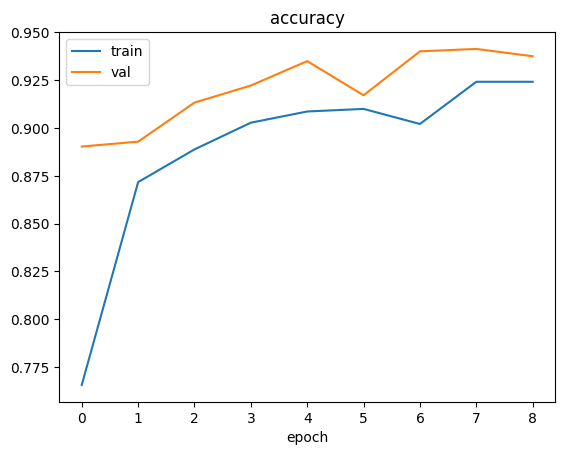

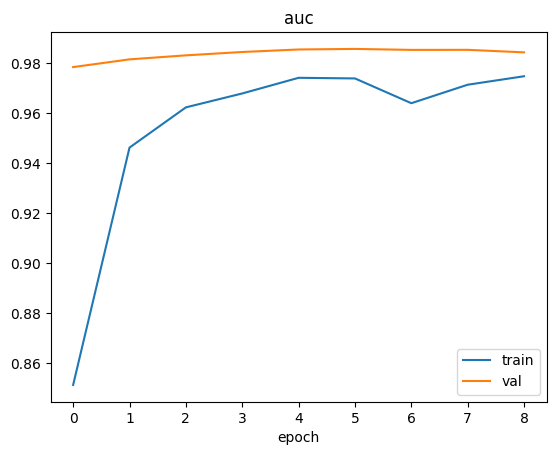

In [ ]:
# Training curves (figure for the report)
def plot_history(hists, key):
    tr = sum([h.history[key] for h in hists], [])
    va = sum([h.history["val_"+key] for h in hists], [])
    plt.plot(tr, label="train"); plt.plot(va, label="val")
    plt.title(key); plt.xlabel("epoch"); plt.legend(); plt.show()
plot_history([hist1,hist2], "accuracy")
plot_history([hist1,hist2], "auc")

## Evaluating the CNN

The CNN is evaluated using the same metrics as the classical machine learning models, including **Accuracy**, **Precision**, **Recall**, **F1-Score**, **Confusion Matrix**, and **ROC-AUC**. Using the same evaluation criteria ensures a fair comparison between the two approaches. ROC curves for both pipelines are also plotted together to visualize and compare their classification performance across different decision thresholds.


20/20 ━━━━━━━━━━━━━━━━━━━━ 31s 870ms/step

===== DenseNet121 (transfer learning) =====
              precision    recall  f1-score   support

      NORMAL      0.918     0.667     0.772       234
   PNEUMONIA      0.828     0.964     0.891       390

    accuracy                          0.853       624
   macro avg      0.873     0.815     0.832       624
weighted avg      0.862     0.853     0.846       624

ROC-AUC: 0.957


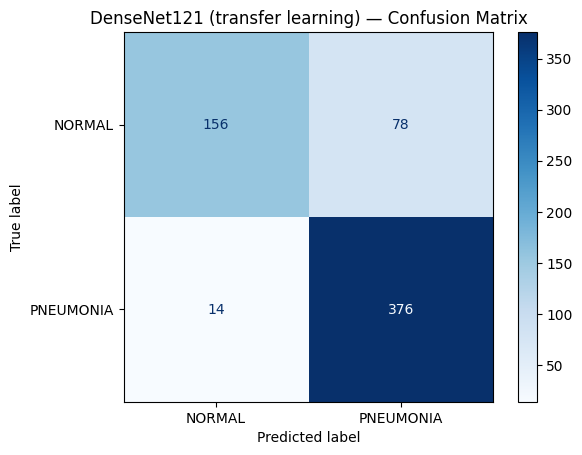

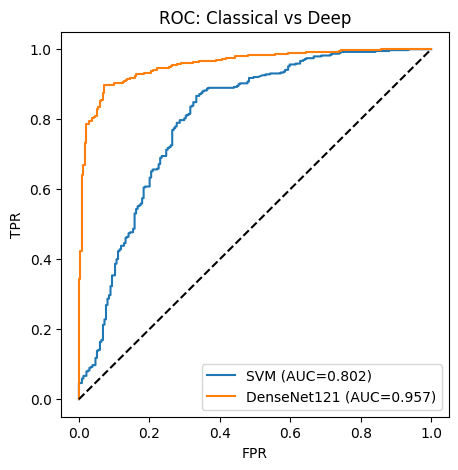

In [ ]:
y_true = np.concatenate([y.numpy() for _, y in test_ds]).ravel().astype(int)
y_prob = model.predict(test_ds).ravel()
y_pred = (y_prob >= 0.5).astype(int)

cnn_res = evaluate("DenseNet121 (transfer learning)", y_true, y_pred, y_prob)

# ROC curves: classical vs deep, on one plot
plt.figure(figsize=(5,5))
for label, score in [("SVM", svm.predict_proba(Xte)[:,1]),
                     ("DenseNet121", y_prob)]:
    yt = yte if label=="SVM" else y_true
    fpr, tpr, _ = roc_curve(yt, score)
    plt.plot(fpr, tpr, label=f"{label} (AUC={roc_auc_score(yt,score):.3f})")
plt.plot([0,1],[0,1],"k--"); plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("ROC: Classical vs Deep"); plt.legend(); plt.savefig("roc_compare.png", dpi=130); plt.show()

## Grad-CAM: Model Interpretation

To improve model interpretability, Grad-CAM (Gradient-weighted Class Activation Mapping) is used to visualize the regions of an X-ray image that contribute most to the CNN's prediction. The resulting heatmaps help verify whether the model is focusing on clinically relevant areas, such as the lungs, rather than unrelated image artifacts. This provides valuable insight into the model's decision-making process and helps assess the reliability of its predictions.


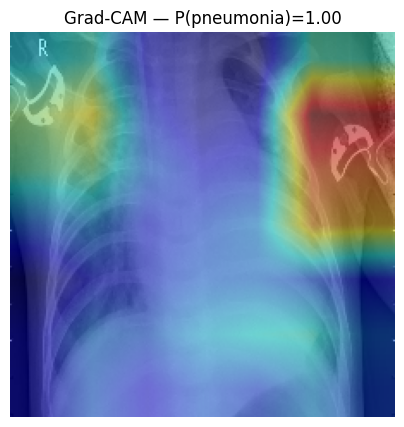

In [ ]:
# Build a feature extractor (image -> last conv maps) and a head (conv maps -> prediction).
feature_extractor = Model(base.input, base.output)
hin  = Input(base.output.shape[1:])
head = pred(drop(gap(hin)))          # reuse the SAME trained layers
head_model = Model(hin, head)

def grad_cam(gray_u8):
    rgb = to_rgb(preprocess_gray(gray_u8, "median", "clahe")).astype("float32")
    x   = densenet_pre(np.expand_dims(rgb, 0))
    with tf.GradientTape() as tape:
        conv = feature_extractor(x); tape.watch(conv)
        p = head_model(conv)
    grads = tape.gradient(p, conv)[0]
    weights = tf.reduce_mean(grads, axis=(0,1))
    cam = tf.nn.relu(tf.reduce_sum(conv[0]*weights, axis=-1)).numpy()
    cam = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
    cam = (cam - cam.min())/(cam.max()-cam.min()+1e-8)
    heat = cv2.applyColorMap((cam*255).astype("uint8"), cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(to_rgb(cv2.resize(gray_u8,(IMG_SIZE,IMG_SIZE))),0.6,
                              heat,0.4,0)
    return overlay, float(p.numpy().ravel()[0])

demo = cv2.imread(os.path.join(TEST_DIR,"PNEUMONIA",
        os.listdir(os.path.join(TEST_DIR,"PNEUMONIA"))[0]), cv2.IMREAD_GRAYSCALE)
overlay, prob = grad_cam(demo)
plt.figure(figsize=(5,5)); plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title(f"Grad-CAM — P(pneumonia)={prob:.2f}"); plt.axis("off")
plt.savefig("gradcam_demo.png", dpi=130, bbox_inches="tight"); plt.show()

## Saving the Models

The trained models and evaluation results are saved to Google Drive to ensure they persist beyond the current Colab session. In addition, a compressed archive is created for convenient download and deployment, allowing the models to be integrated into the Streamlit application without retraining.


In [ ]:
import joblib
# Save into your Drive project folder so the models persist after the session ends.
ART_DIR = "/content/drive/MyDrive/Colab Notebooks/PCD Final Project/artifacts"
os.makedirs(ART_DIR, exist_ok=True)

model.save(os.path.join(ART_DIR, "densenet_pneumonia.keras"))     # deep model
joblib.dump(svm, os.path.join(ART_DIR, "svm_pneumonia.joblib"))   # classical model

results = {"svm": svm_res, "rf": rf_res, "cnn": cnn_res,
           "classes": CLASSES, "img_size": IMG_SIZE}
with open(os.path.join(ART_DIR, "results.json"), "w") as f:
    json.dump(results, f, indent=2)

# Also zip a local copy you can download for the Streamlit app
shutil.make_archive("pneumovision_artifacts", "zip", ART_DIR)
from google.colab import files
files.download("pneumovision_artifacts.zip")
print("Saved models + metrics to your Drive (artifacts/) and zipped for download.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved models + metrics to your Drive (artifacts/) and zipped for download.
